# **TIỀN XỬ LÝ DỮ LIỆU (DATA PREPROCESSING)**

*Thực hiện quy trình: Làm sạch → Mã hóa → Chuẩn hóa → Chia tập train/test*
***

## **0. Cài đặt thư viện và thiết lập**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
DATA_PATH = "../data/IBM.csv"

# **1. Load dữ liệu và làm sạch**

In [3]:
df = pd.read_csv(DATA_PATH)
df.head()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
1,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
2,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
3,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
4,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      1470 non-null   int64
 1   Attrition                1470 non-null   str  
 2   Department               1470 non-null   str  
 3   DistanceFromHome         1470 non-null   int64
 4   Education                1470 non-null   int64
 5   EducationField           1470 non-null   str  
 6   EnvironmentSatisfaction  1470 non-null   int64
 7   JobSatisfaction          1470 non-null   int64
 8   MaritalStatus            1470 non-null   str  
 9   MonthlyIncome            1470 non-null   int64
 10  NumCompaniesWorked       1470 non-null   int64
 11  WorkLifeBalance          1470 non-null   int64
 12  YearsAtCompany           1470 non-null   int64
dtypes: int64(9), str(4)
memory usage: 149.4 KB


In [5]:
# Xóa khoảng trắng thừa ở tên các cột 
df.columns = df.columns.str.strip()

# Xóa khoảng trắng thừa ở các cột dữ liệu dạng chữ (object)
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

In [6]:
print("Giá trị thiếu: ", df.isnull().sum().sum())
print("Trùng lặp: ", df.duplicated().sum())
print("Shape: ", df.shape)

Giá trị thiếu:  0
Trùng lặp:  0
Shape:  (1470, 13)


# **2. Xác định biến mục tiêu và đặc trưng**

In [8]:
TARGET = "Attrition"
X = df.drop(columns=[TARGET])
y = df[TARGET].map({
    "Yes": 1,
    "No": 0
})

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Biến số ({len(numeric_features)}): {numeric_features}")
print(f"Biến phân loại ({len(categorical_features)}): {categorical_features}")
print(f"\nPhân bố y: \n {y.value_counts().rename(index={0: 'No (ở lại)', 1: 'Yes (nghỉ)'})}")

Biến số (9): ['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'WorkLifeBalance', 'YearsAtCompany']
Biến phân loại (3): ['Department', 'EducationField', 'MaritalStatus']

Phân bố y: 
 Attrition
No (ở lại)    1233
Yes (nghỉ)     237
Name: count, dtype: int64


*Nhận xét:* Dữ liệu bị mất cân bằng lớp nghiêm trọng, khi chia tập train/test cần tham số `stratify=y`

## **3. Chia train/test với stratify**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} mẫu | Test: {X_test.shape[0]} mẫu")
print(f"Tỷ lệ Yes trong train: {y_train.mean():.3f}")
print(f"Tỷ lệ Yes trong test:  {y_test.mean():.3f}")
print("=> `stratify=y` giữ tỷ lệ lớp nhất quán giữa train và test.")


Train: 1176 mẫu | Test: 294 mẫu
Tỷ lệ Yes trong train: 0.162
Tỷ lệ Yes trong test:  0.160
=> `stratify=y` giữ tỷ lệ lớp nhất quán giữa train và test.


## **4. Pipline preprocessing**

Dùng `ColumnTransformer` + `Pipeline` để:
- StandardScaler cho biến số

- OneHotEncoder cho biến phân loại

- Tất cả trong Pipeline để tránh data leakage khi fit chỉ trên tập train

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)

cat_names = preprocessor.transformers_[1][1].get_feature_names_out(categorical_features).tolist()

all_names = numeric_features + cat_names

print(f"Số đặc trưng ban đầu: {X_train.shape[1]}")
print(f"Số đặc trưng sau encoding: {X_train_t.shape[1]}")
print(f"\nTên tất cả đặc trưng mới: \n{all_names}")

Số đặc trưng ban đầu: 12
Số đặc trưng sau encoding: 21

Tên tất cả đặc trưng mới: 
['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'WorkLifeBalance', 'YearsAtCompany', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single']


## **5. Kiểm tra phân bố sau chuẩn hóa**

In [11]:
# Kiểm tra biến số đã được chuẩn hóa về mean≈0, std≈1
train_scaled = pd.DataFrame(X_train_t[:, :len(numeric_features)], columns=numeric_features)
print("Mean (gần 0):")
print(train_scaled.mean().round(6))
print("\nStd (gần 1):")
print(train_scaled.std().round(6))

Mean (gần 0):
Age                       -0.0
DistanceFromHome          -0.0
Education                  0.0
EnvironmentSatisfaction    0.0
JobSatisfaction            0.0
MonthlyIncome             -0.0
NumCompaniesWorked        -0.0
WorkLifeBalance           -0.0
YearsAtCompany            -0.0
dtype: float64

Std (gần 1):
Age                        1.000425
DistanceFromHome           1.000425
Education                  1.000425
EnvironmentSatisfaction    1.000425
JobSatisfaction            1.000425
MonthlyIncome              1.000425
NumCompaniesWorked         1.000425
WorkLifeBalance            1.000425
YearsAtCompany             1.000425
dtype: float64


## **6. Xử lý mất cân bằng lớp**

Dataset có 16.1% Yes - mất cân bằng khá nặng. Chiến lược xử lý:
- Dùng `class_weight='balanced'` cho các mô hình hỗ trợ (Logistic Regression, Decision Tree, Random Forest)

- KNN không hỗ trợ `class_weight` => cần lưu ý

> **Hướng cải thiện:** Kết hợp SMOTE (oversampling lớp thiểu số) để tạo thêm mẫu tổng hợp trước khi train.

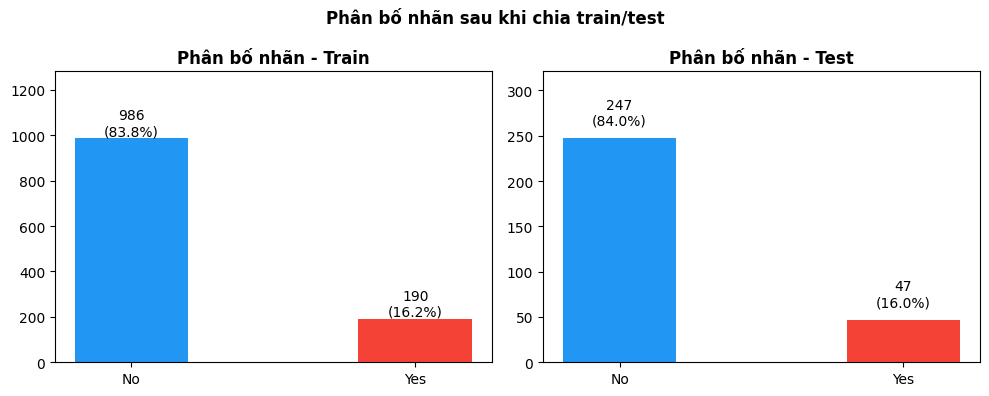

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split_name, y_split) in zip(axes, [("Train", y_train), ("Test", y_test)]):
    counts = y_split.value_counts().rename(index={0:"No",1:"Yes"})
    ax.bar(counts.index, counts.values, color=["#2196F3","#F44336"], width=0.4)
    ax.set_title(f"Phân bố nhãn - {split_name}", fontweight="bold")
    for i, (_, v) in enumerate(counts.items()):
        ax.text(i, v+15, f"{v}\n({v/len(y_split):.1%})", ha="center", fontsize=10)
    ax.set_ylim(0, counts.max()*1.3)
plt.suptitle("Phân bố nhãn sau khi chia train/test", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## **7. Tổng kết preprocessing**

| Bước | Mô tả | Kết quả |
|---|---|---|
| Làm sạch | Không có missing/duplicate | Không cần xử lý |
| Mã hóa mục tiêu | Yes→1, No→0 | OK |
| Chia train/test | 80/20, stratify=y | 1176 / 294 |
| StandardScaler | Biến số (9 cột) | mean≈0, std≈1 |
| OneHotEncoder | Biến phân loại (3 cột) | 15 cột mới |
| Tổng đặc trưng sau encode | — | 24 cột |
| Xử lý mất cân bằng | class_weight='balanced' | Trong Pipeline |